# The Gram matrix along the transport

One run, everything about the per-step linear solves in one place:

1. **Conditioning**: how close G is to singular at each step, and which statistics cause it
2. **Masking**: which statistics were switched off (coefficient set to 0), and when
3. **Moment matching**: how well the walkers hit the target moments, which ones miss, and when
4. **Coefficient spikes**: statistics whose θ suddenly jumps, and what was going on at that moment
5. **Discrepancy principle**: the supervisor's stopping rule replayed on the logged steps
6. **Summary**: one table per statistic

**Inputs** (all written by `run_SDE.py`, nothing is recomputed from the samples):

| file | what | needed |
|---|---|---|
| `saved_results/aux_moments/<config>_cond.pt` | conditioning log, every `--cond_every` steps | sections 1, 5 |
| `saved_results/aux_moments/<config>_aux_moments.pt` | target and walker moments at every step | section 3 |
| `saved_results/lagrange_multipliers/<config>.pt` | θ at every step (0 exactly = masked) | sections 2, 4 |
| `saved_results/sampling_times/<config>.pt` | the time grid | all |

**Runs still in progress.** With `--cond_every`, the conditioning log is also written *during* the run,
every 2000 steps (same file, overwritten; the final save replaces it with the complete log). The other
three files only exist at the end. While a run is going, the notebook rebuilds the time grid from the
run's `config.json` (fixed grids only: `power`, `two_phase`) and shows what the log allows: sections 1, 2b
(live count and margins) and 5. `CONFIG` may be a glob pattern, e.g. `'*seed_901_*noL6psi*'`.

Run from `turbulence/` (on Jean Zay the files are already there; locally after a `pull_results`).
Light enough for a login node: the largest file is ~130 MB.

**Words used below.**
* *G* : the Gram matrix of the statistics' gradients on the walkers, $G_{nm}=\frac1N\sum_i\nabla\phi_n(x^i)\cdot\nabla\phi_m(x^i)$. Each step solves $G c = b$ twice: predictor (η) and corrector (θ).
* *scaled G* : G divided by its diagonal, so every statistic has weight 1 ($\tilde G_{nn}=1$). The run adds the ridge ε to this one.
* *κ (condition number)* : largest / smallest eigenvalue of the scaled G. κ = 10⁸ means one direction of the coefficients is 10⁸ times less determined by the data than another.
* *smallest eigen-direction* : the combination of statistics G can barely see. If it is ≈ (stat a − stat b)/√2, a and b are near-copies.
* *masked / dead* : statistic whose gradient almost vanished on the walkers (its region is empty); its coefficient is set to 0 for that step.
* *own-scale error* : |target − walkers| / (largest |target| over the run). Unlike the relative error, it doesn't blow up when a target crosses 0.

In [21]:
import os, sys
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

ARM = 'reg1e-4'
SEED = 900           # 900..904
CONFIG = ('turbulencesynth_M256_J8_Q3_sigma3.5_nt60000_n1_8500_lam0.0_thomas_nsub1_moment_f64_dedupfilt1e-08'
          f'_seed_{SEED}_terms54d17f3b_zfloor_two_phase_noL6psi_noSm30_{ARM}_20261001_1911')

LATE_T = 0.95          # the end phase where the moment error jumps (two-phase schedule)
ERR_TARGET = 1e-2      # own-scale error counted as a miss
MOMENT_THRESHOLD = 1e-8  # moments with |final target| below this are skipped (as compare_moment_matching)
SPIKE_FACTOR = 100.    # a theta spike = |theta_n| > SPIKE_FACTOR x its running median
SPIKE_WINDOW = 201     # steps in the running median (odd)
SAVE_FIGS = False      # True: save every figure in figures/gram_along_transport/<short config>/

sr = ROOT / 'saved_results'
FIGDIR = ROOT / 'figures' / 'gram_along_transport' / CONFIG[-40:]
if SAVE_FIGS:
    FIGDIR.mkdir(parents=True, exist_ok=True)

def savefig(fig, name):
    if SAVE_FIGS:
        fig.savefig(FIGDIR / f'{name}.png', dpi=130, bbox_inches='tight')

def load(p):
    if not p.exists() and p.with_suffix('').exists():     # runs saved before the .pt convention
        p = p.with_suffix('')
    return torch.load(p, map_location='cpu', weights_only=False) if p.exists() else None

if '*' in CONFIG:                                      # glob pattern: the newest matching run
    hits = sorted((sr / 'aux_moments').glob(f'{CONFIG}_cond.pt'), key=lambda f: f.stat().st_mtime)
    hits += [f for f in sorted((sr / 'sampling_times').glob(f'{CONFIG}.pt'), key=lambda f: f.stat().st_mtime)
             if f.stem not in {h.name[:-len('_cond.pt')] for h in hits}]
    assert hits, f'no run matches {CONFIG!r}'
    for h in hits:
        print('  match:', h.name)
    CONFIG = hits[-1].name[:-len('_cond.pt')] if hits[-1].name.endswith('_cond.pt') else hits[-1].stem
    print('using:', CONFIG)

t_grid = load(sr / 'sampling_times' / f'{CONFIG}.pt')
cond = load(sr / 'aux_moments' / f'{CONFIG}_cond.pt')
aux = load(sr / 'aux_moments' / f'{CONFIG}_aux_moments.pt')
theta = load(sr / 'lagrange_multipliers' / f'{CONFIG}.pt')
for name, obj in [('sampling_times', t_grid), ('cond log', cond), ('aux moments', aux), ('theta_t', theta)]:
    print(f'{name:15s}', 'MISSING' if obj is None else 'ok')
PARTIAL = cond is not None and (aux is None or theta is None or t_grid is None)
if t_grid is None:
    # run still going: rebuild the grid from the run's config.json (written at the start)
    import json
    from types import SimpleNamespace
    REPO = Path(os.environ.get('GAT_REPO', ROOT.resolve().parent))   # the repo holds codes/
    for d in (REPO, REPO / 'codes'):
        if str(d) not in sys.path:
            sys.path.insert(0, str(d))
    from codes.time_schedules import build_time_grid
    exp_dirs = list((ROOT / 'experiments').glob(f'*/{CONFIG}')) + list((ROOT / 'experiments').glob(CONFIG))
    assert exp_dirs, f'no time grid and no experiments/*/{CONFIG}/config.json to rebuild it from'
    cfg = json.load(open(exp_dirs[0] / 'config.json'))
    assert cfg.get('schedule', 'power') in ('power', 'two_phase'), \
        f"schedule {cfg.get('schedule')!r}: its grid is only known at the end of the run"
    t_grid, _ = build_time_grid(SimpleNamespace(**cfg), logger=None)
    print('time grid rebuilt from config.json')
t_grid = np.asarray(t_grid, dtype=np.float64)
if PARTIAL:
    k_last = int(cond['theta'][-1, 0]) if len(cond['theta']) else 0
    print(f'\n*** RUN IN PROGRESS: conditioning log up to step {k_last} of {len(t_grid) - 1} '
          f'(t = {t_grid[min(k_last + 1, len(t_grid) - 1)]:.5f}). Sections 2 (mask table), 3, 4 need the '
          f'finished run. ***')

sampling_times  ok
cond log        ok
aux moments     ok
theta_t         ok


In [22]:
# statistic names: from the conditioning log (same order as the solves); otherwise rebuilt
# from the run's fitted potentials (needs experiments/<...>/fitted_potentials).
labels = list(cond['labels']) if cond is not None else None
if labels is None:
    for d in (ROOT.resolve().parent, ROOT.resolve().parent / 'codes', ROOT.resolve().parent / 'data'):
        sys.path.insert(0, str(d))
    from codes.find_duplicate_statistics import statistic_labels
    labels, _ = statistic_labels(ROOT, CONFIG)
r = len(labels)
family = np.array([l.split('[')[0] for l in labels])
families = list(dict.fromkeys(family))
print(f'{r} statistics in {len(families)} families:')
for f in families:
    idx = np.flatnonzero(family == f)
    print(f'  {f:40s} global {idx[0]:3d}..{idx[-1]:3d}  ({len(idx)})')

def tx(t):
    '''x-axis: 1 - t on a log scale (the two-phase grid spends half its steps in t > 0.9).'''
    return np.maximum(1 - np.asarray(t), 1e-7)

def time_axis(ax, late=True):
    ax.set_xscale('log'); ax.invert_xaxis(); ax.set_xlabel('1 - t   (t = 1 on the right)')
    if late:
        ax.axvline(1 - LATE_T, color='grey', ls=':', lw=1)

258 statistics in 6 families:
  L_6                                      global   0..  8  (9)
  L_2_lowpass                              global   9..  9  (1)
  Scalar_psi_gaussianK                     global  10.. 87  (78)
  Scalar_morlet_gaussianK                  global  88..117  (30)
  Scattering_Fourth_Order_Mod2_Real_Q1     global 118..201  (84)
  Scattering_Fourth_Order_Mod2_Imag_Q1     global 202..257  (56)


## 1. Conditioning along the transport

From the conditioning log, every `cond_every` steps, for both solves: κ of the scaled G **before** the
ridge, on the live (non-masked) statistics only, and the 3 statistics with the largest weight in the
smallest eigen-direction.

Reading κ with the ridge ε: a direction with eigenvalue μ ≪ ε gets its coefficient from ε, not from
the data. So the log also shows **how many eigenvalues are below ε**: the number of coefficient
combinations that are set by the ridge.

eta: mu_min <= 0 (unresolved, kappa undefined) at 0/6000 logged steps
theta: mu_min <= 0 (unresolved, kappa undefined) at 0/6000 logged steps


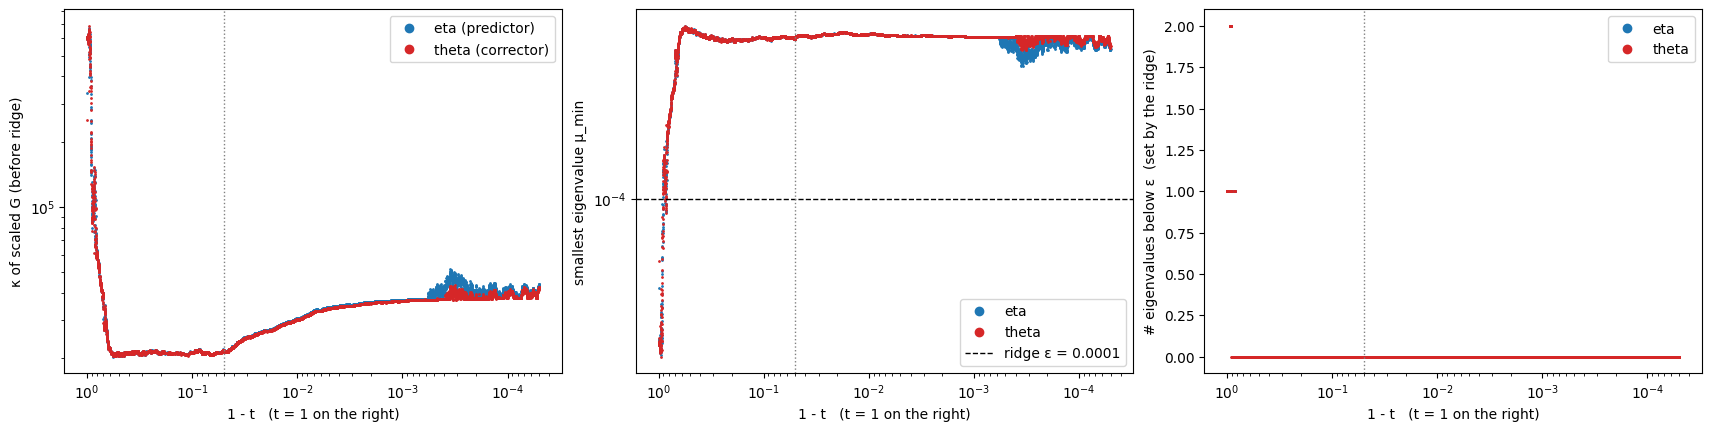

          t band |   κ θ med   κ θ max  #μ<ε θ |   κ η med   κ η max  #μ<ε η
   [0.000,0.100) |  5.70e+05  6.85e+05       1 |  5.65e+05  6.73e+05       1 |
   [0.100,0.500) |  3.47e+04  1.52e+05       0 |  3.47e+04  1.51e+05       0 |
   [0.500,0.900) |  2.11e+04  2.18e+04       0 |  2.11e+04  2.18e+04       0 |
   [0.900,0.950) |  2.12e+04  2.19e+04       0 |  2.13e+04  2.20e+04       0 |
   [0.950,0.990) |  2.62e+04  3.02e+04       0 |  2.64e+04  3.05e+04       0 |
   [0.990,0.999) |  3.49e+04  3.69e+04       0 |  3.53e+04  3.73e+04       0 |
   [0.999,1.000) |  3.78e+04  4.33e+04       0 |  4.04e+04  5.15e+04       0 |


In [23]:
if cond is not None:
    cols = list(cond['columns'])
    C = {name: cond[name].numpy() for name in ('eta', 'theta')}
    S = {name: cond[f'{name}_spectra'].double().numpy() for name in ('eta', 'theta')}
    eps = float(cond['regularization'])
    # step k of the log: eta at t[k], theta at t[k+1]
    tC = {'eta': t_grid[np.minimum(C['eta'][:, 0].astype(int), len(t_grid) - 1)],
          'theta': t_grid[np.minimum(C['theta'][:, 0].astype(int) + 1, len(t_grid) - 1)]}
    pos = {n: C[n][:, 2] > 0 for n in C}                       # mu_min <= 0: below float32 resolution of G
    kap = {n: np.where(pos[n], C[n][:, 3] / np.where(pos[n], C[n][:, 2], 1.0), np.nan) for n in C}
    for n in C:
        print(f'{n}: mu_min <= 0 (unresolved, kappa undefined) at {(~pos[n]).sum()}/{len(pos[n])} logged steps')
    n_below = {n: np.sum(S[n][:, 0, :] < eps, axis=1) for n in C}       # NaN padding compares False

    fig, ax = plt.subplots(1, 3, figsize=(17, 4.2), constrained_layout=True)
    for n, c in [('eta', 'C0'), ('theta', 'C3')]:
        ax[0].plot(tx(tC[n]), kap[n], '.', ms=2, color=c, label=f'{n} (predictor)' if n == 'eta' else f'{n} (corrector)')
        ax[1].plot(tx(tC[n]), C[n][:, 2], '.', ms=2, color=c, label=n)
        ax[2].plot(tx(tC[n]), n_below[n], '.', ms=2, color=c, label=n)
    ax[0].set_yscale('log'); ax[0].set_ylabel('κ of scaled G (before ridge)'); ax[0].legend(markerscale=6)
    ax[1].set_yscale('symlog', linthresh=1e-12); ax[1].axhline(eps, color='k', ls='--', lw=1, label=f'ridge ε = {eps:g}')
    ax[1].set_ylabel('smallest eigenvalue μ_min'); ax[1].legend(markerscale=6)
    ax[2].set_ylabel(f'# eigenvalues below ε  (set by the ridge)'); ax[2].legend(markerscale=6)
    for a in ax: time_axis(a)
    #savefig(fig, '1_conditioning'); 
    %matplotlib inline
    plt.show()

    bands = [(0, .1), (.1, .5), (.5, .9), (.9, LATE_T), (LATE_T, .99), (.99, .999), (.999, 1.0001)]
    print(f'{"t band":>16} | {"κ θ med":>9} {"κ θ max":>9} {"#μ<ε θ":>7} | {"κ η med":>9} {"κ η max":>9} {"#μ<ε η":>7}')
    for lo, hi in bands:
        row = f'[{lo:.3f},{min(hi,1):.3f})'.rjust(16) + ' |'
        for n in ('theta', 'eta'):
            s = (tC[n] >= lo) & (tC[n] < hi)
            row += (f' {np.nanmedian(kap[n][s]):9.2e} {np.nanmax(kap[n][s]):9.2e} {np.median(n_below[n][s]):7.0f} |'
                    if s.any() else f' {"-":>9} {"-":>9} {"-":>7} |')
        print(row)
else:
    print('no conditioning log for this run (launched without --cond_every)')

In [24]:
# Best possible kappa after removing k statistics (interlacing: new mu_min <= mu_{k+1})
if cond is not None:
    mu = S['theta'][:, 0, :]                     # eigenvalues, ascending, NaN-padded
    lmax = C['theta'][:, 3]
    print(f'{"t band":>16} | ' + ' | '.join(f'k={k}: μ_{k+1} med   κ best' for k in range(4)))
    for lo, hi in bands:
        s = (tC['theta'] >= lo) & (tC['theta'] < hi)
        if not s.any():
            continue
        row = f'[{lo:.3f},{min(hi,1):.3f})'.rjust(16)
        for k in range(4):
            m = mu[s, k]
            row += f' | {np.nanmedian(m):10.2e} {np.nanmedian(lmax[s] / np.where(m > 0, m, np.nan)):9.2e}'
        print(row)

          t band | k=0: μ_1 med   κ best | k=1: μ_2 med   κ best | k=2: μ_3 med   κ best | k=3: μ_4 med   κ best
   [0.000,0.100) |   2.36e-05  5.70e+05 |   2.35e-04  5.67e+04 |   8.25e-04  1.62e+04 |   1.21e-03  1.10e+04
   [0.100,0.500) |   3.63e-04  3.47e+04 |   2.42e-03  5.21e+03 |   4.42e-03  2.84e+03 |   6.23e-03  2.05e+03
   [0.500,0.900) |   5.30e-04  2.11e+04 |   3.87e-03  2.88e+03 |   8.21e-03  1.36e+03 |   1.01e-02  1.11e+03
   [0.900,0.950) |   5.31e-04  2.12e+04 |   4.18e-03  2.70e+03 |   9.07e-03  1.24e+03 |   1.15e-02  9.83e+02
   [0.950,0.990) |   5.48e-04  2.62e+04 |   4.20e-03  3.43e+03 |   9.15e-03  1.55e+03 |   1.02e-02  1.41e+03
   [0.990,0.999) |   5.41e-04  3.49e+04 |   3.26e-03  5.84e+03 |   4.26e-03  4.43e+03 |   5.10e-03  3.70e+03
   [0.999,1.000) |   5.34e-04  3.78e+04 |   5.43e-04  3.73e+04 |   2.98e-03  6.81e+03 |   4.20e-03  4.82e+03


### Which statistics make G nearly singular

For each logged step, the statistic with the largest weight in the smallest eigen-direction (`top0`),
and the two next ones. A pair that keeps coming back together is a near-copy (cf. the 1 Oct note:
L_6[7] ≈ L_6_psi[20], L_6[8] ≈ L_6_psi[21], Scalar_morlet[30] ≈ Scalar_psi[77]).

--- theta: most frequent top-2 pairs of the smallest eigen-direction (6000 logged steps)
   4667 steps ( 77.8%)  t in [0.3799, 0.999947]  median κ 3.27e+04   Scalar_psi_gaussianK[54]  +  Scalar_morlet_gaussianK[29]
    804 steps ( 13.4%)  t in [0.9996, 0.999949]  median κ 3.93e+04   Scattering_Fourth_Order_Mod2_Real_Q1[5]  +  Scattering_Fourth_Order_Mod2_Real_Q1[11]
    224 steps (  3.7%)  t in [0.1738, 0.378990]  median κ 4.07e+04   Scalar_psi_gaussianK[32]  +  Scalar_morlet_gaussianK[29]
    101 steps (  1.7%)  t in [0.9995, 0.999950]  median κ 3.94e+04   Scattering_Fourth_Order_Mod2_Real_Q1[4]  +  Scattering_Fourth_Order_Mod2_Real_Q1[5]
     93 steps (  1.6%)  t in [0.0811, 0.177390]  median κ 1.01e+05   L_6[7]  +  Scalar_psi_gaussianK[76]
     50 steps (  0.8%)  t in [0.0010, 0.045990]  median κ 6.07e+05   Scalar_psi_gaussianK[32]  +  Scalar_morlet_gaussianK[20]
     29 steps (  0.5%)  t in [0.0001, 0.079290]  median κ 4.41e+05   Scalar_psi_gaussianK[32]  +  Scalar_psi_gaussianK[76

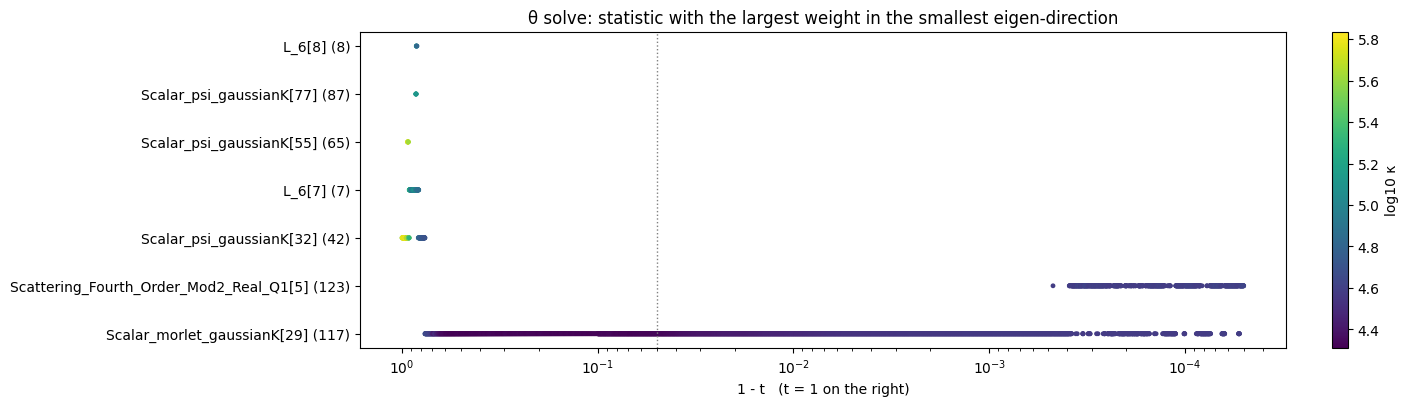

In [25]:
if cond is not None:
    from collections import Counter
    i0 = cols.index('top0')
    for n in ('theta', 'eta'):
        trip = [tuple(int(v) for v in row[i0:i0 + 3] if v >= 0) for row in C[n]]
        pair = Counter(tuple(sorted(tr[:2])) for tr in trip if len(tr) >= 2)
        print(f'--- {n}: most frequent top-2 pairs of the smallest eigen-direction ({len(trip)} logged steps)')
        for (a, b), c in pair.most_common(8):
            s = np.array([len(tr) >= 2 and tuple(sorted(tr[:2])) == (a, b) for tr in trip])
            print(f'  {c:5d} steps ({100*c/len(trip):5.1f}%)  t in [{tC[n][s].min():.4f}, {tC[n][s].max():.6f}]  '
                  f'median κ {np.nanmedian(kap[n][s]):.2e}   {labels[a]}  +  {labels[b]}')

    # the same, over time: one row per statistic that is ever top0
    n = 'theta'
    top0 = C[n][:, i0].astype(int)
    ever = [i for i, _ in Counter(top0[top0 >= 0]).most_common(12)]
    fig, ax = plt.subplots(figsize=(14, 0.35 * len(ever) + 1.5), constrained_layout=True)
    for row, i in enumerate(ever):
        s = top0 == i
        sc = ax.scatter(tx(tC[n][s]), np.full(s.sum(), row), c=np.log10(kap[n][s]), s=6,
                        cmap='viridis', vmin=np.log10(np.nanmin(kap[n])), vmax=np.log10(np.nanmax(kap[n])))
    ax.set_yticks(range(len(ever)), [f'{labels[i]} ({i})' for i in ever])
    time_axis(ax); ax.set_title('θ solve: statistic with the largest weight in the smallest eigen-direction')
    fig.colorbar(sc, ax=ax, label='log10 κ')
    savefig(fig, '1b_smallest_direction'); plt.show()

## 2. Masking: which statistics were switched off, and when

A statistic is **masked** at a step when its Gram diagonal is below its threshold (only the region
statistics `Scalar_*_gaussianK` have a non-zero threshold: 10⁻⁶ of the data value). Its coefficient is
then exactly 0, so the mask is read from the saved θ: **θ_n = 0 exactly ⇔ masked in the corrector**.
(The predictor η uses the same rule on the walkers before the predictor step; η is not saved, but the
conditioning log has its live count.)

Also shown: the **margin** = smallest (Gram diagonal / threshold) among the live thresholded statistics.
A margin close to 1 means some region is about to empty.

theta_t: 60000 steps x 258 statistics; 4 statistics masked at least once
 stat name                                    #steps #episodes    first t     last t   episodes (t ranges, first 4)
   43 Scalar_psi_gaussianK[33]                   597         7      9e-05    0.05454   [9e-05,0.02133]  [0.0216,0.02187]  [0.02223,0.05373]  [0.05391,0.054] ...
   65 Scalar_psi_gaussianK[55]                   482         3      9e-05    0.04392   [9e-05,0.02133]  [0.02169,0.02187]  [0.02223,0.04392]
   87 Scalar_psi_gaussianK[77]                  1658         2      9e-05     0.1493   [9e-05,0.1491]  [0.1493,0.1493]
  109 Scalar_morlet_gaussianK[21]                236         1      9e-05    0.02124   [9e-05,0.02124]


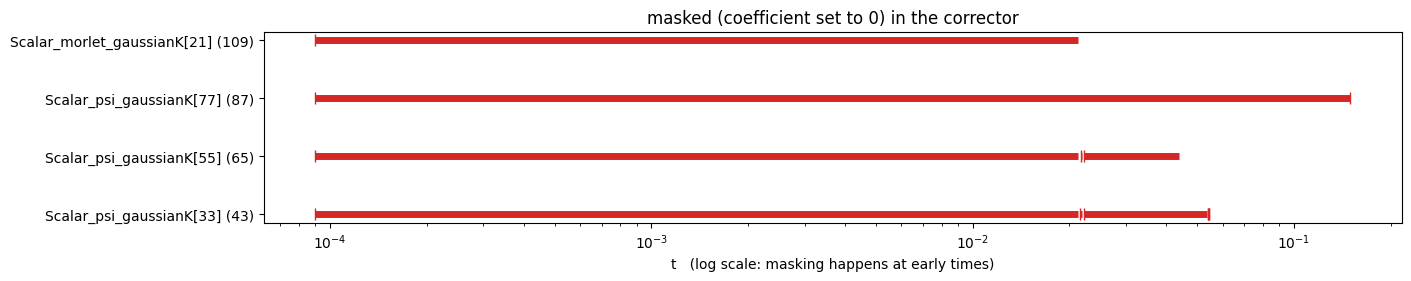

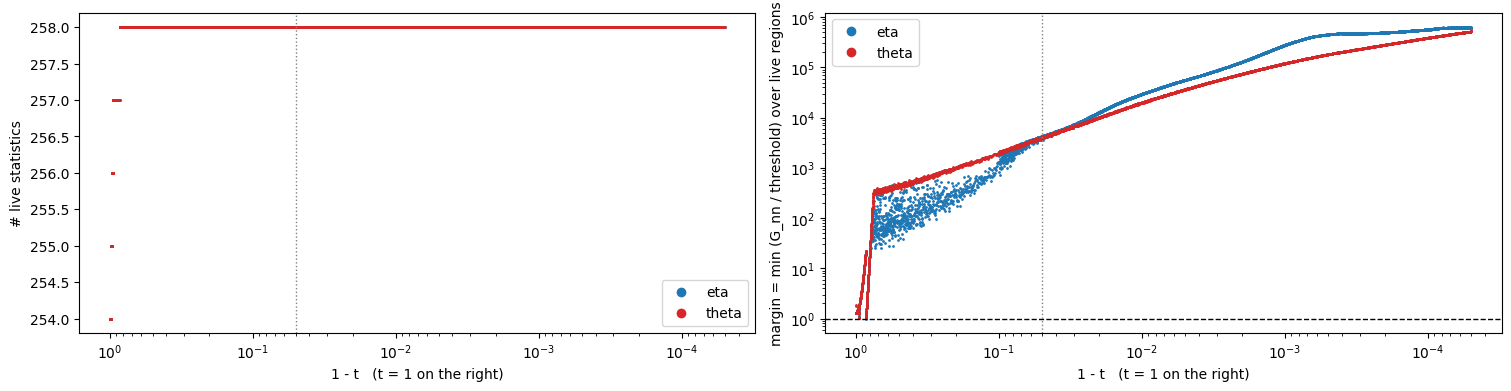

closest calls in the theta solve (live region nearest to its threshold):
  t=0.149490  margin     1.01  Scalar_psi_gaussianK[77] (87)
  t=0.044190  margin     1.01  Scalar_psi_gaussianK[55] (65)
  t=0.054090  margin     1.02  Scalar_psi_gaussianK[33] (43)
  t=0.150390  margin     1.07  Scalar_psi_gaussianK[77] (87)
  t=0.045090  margin     1.10  Scalar_psi_gaussianK[55] (65)
  t=0.151290  margin     1.11  Scalar_psi_gaussianK[77] (87)
  t=0.152190  margin     1.18  Scalar_psi_gaussianK[77] (87)
  t=0.153090  margin     1.24  Scalar_psi_gaussianK[77] (87)


In [26]:
def runs_of(mask):
    '''[(start, end_exclusive), ...] of the True runs of a 1-D boolean array.'''
    d = np.diff(np.concatenate([[0], mask.astype(np.int8), [0]]))
    return list(zip(np.flatnonzero(d == 1), np.flatnonzero(d == -1)))

if theta is not None:
    TH = theta.double().numpy() if torch.is_tensor(theta) else np.asarray(theta, dtype=np.float64)
    TH = TH.reshape(TH.shape[0], -1)
    nT = TH.shape[0]
    tT = t_grid[np.minimum(np.arange(1, nT + 1), len(t_grid) - 1)]     # theta row k at t[k+1]
    dead = TH == 0
    ever_dead = np.flatnonzero(dead.any(0))
    print(f'theta_t: {nT} steps x {TH.shape[1]} statistics; {len(ever_dead)} statistics masked at least once')
    print(f'{"stat":>5} {"name":38s} {"#steps":>7} {"#episodes":>9} {"first t":>10} {"last t":>10}   episodes (t ranges, first 4)')
    mask_table = {}
    for i in ever_dead:
        ep = runs_of(dead[:, i])
        mask_table[i] = ep
        eps_txt = '  '.join(f'[{tT[a]:.4g},{tT[b-1]:.4g}]' for a, b in ep[:4]) + (' ...' if len(ep) > 4 else '')
        print(f'{i:5d} {labels[i]:38s} {dead[:, i].sum():7d} {len(ep):9d} {tT[ep[0][0]]:10.4g} {tT[ep[-1][1]-1]:10.4g}   {eps_txt}')

    if len(ever_dead):
        fig, ax = plt.subplots(figsize=(14, 0.3 * len(ever_dead) + 1.5), constrained_layout=True)
        for row, i in enumerate(ever_dead):
            for a, b in mask_table[i]:
                ax.plot([tT[a], tT[b - 1]], [row, row], lw=5, solid_capstyle='butt', color='C3')
                ax.plot([tT[a]], [row], '|', color='C3', ms=8)
        ax.set_yticks(range(len(ever_dead)), [f'{labels[i]} ({i})' for i in ever_dead])
        ax.set_xscale('log'); ax.set_xlabel('t   (log scale: masking happens at early times)')
        ax.set_title('masked (coefficient set to 0) in the corrector')
        #savefig(fig, '2_mask'); 
        plt.show()

else:
    print('mask table: needs the saved theta_t (written at the end of the run)')

if cond is not None:
    im, imi = cols.index('margin'), cols.index('margin_idx')
    fig, ax = plt.subplots(1, 2, figsize=(15, 3.8), constrained_layout=True)
    for n, c in [('eta', 'C0'), ('theta', 'C3')]:
        ax[0].plot(tx(tC[n]), C[n][:, 1], '.', ms=2, color=c, label=n)
        m = C[n][:, im]; ok = np.isfinite(m)
        ax[1].plot(tx(tC[n][ok]), m[ok], '.', ms=2, color=c, label=n)
    ax[0].set_ylabel('# live statistics'); ax[0].legend(markerscale=6)
    ax[1].set_yscale('log'); ax[1].axhline(1, color='k', ls='--', lw=1)
    ax[1].set_ylabel('margin = min (G_nn / threshold) over live regions'); ax[1].legend(markerscale=6)
    for a in ax: time_axis(a)
    savefig(fig, '2b_live_margin'); plt.show()
    m = C['theta'][:, im]; j = np.argsort(m)[:8]
    print('closest calls in the theta solve (live region nearest to its threshold):')
    for jj in j:
        if np.isfinite(m[jj]):
            i = int(C['theta'][jj, imi])
            print(f'  t={tC["theta"][jj]:.6f}  margin {m[jj]:8.2f}  {labels[i]} ({i})')

## 3. Moment matching

`barphi_e` = target moments (the interpolant), `barphi_p` = walker moments, one row per step.
Error on each moment's own scale, as in `compare_moment_matching.py`.

234/258 moments kept (|final target| > 1e-08)
final step, own scale: median 4.51e-08  p90 3.72e-04  max 1.59e-01  above 0.01: 11


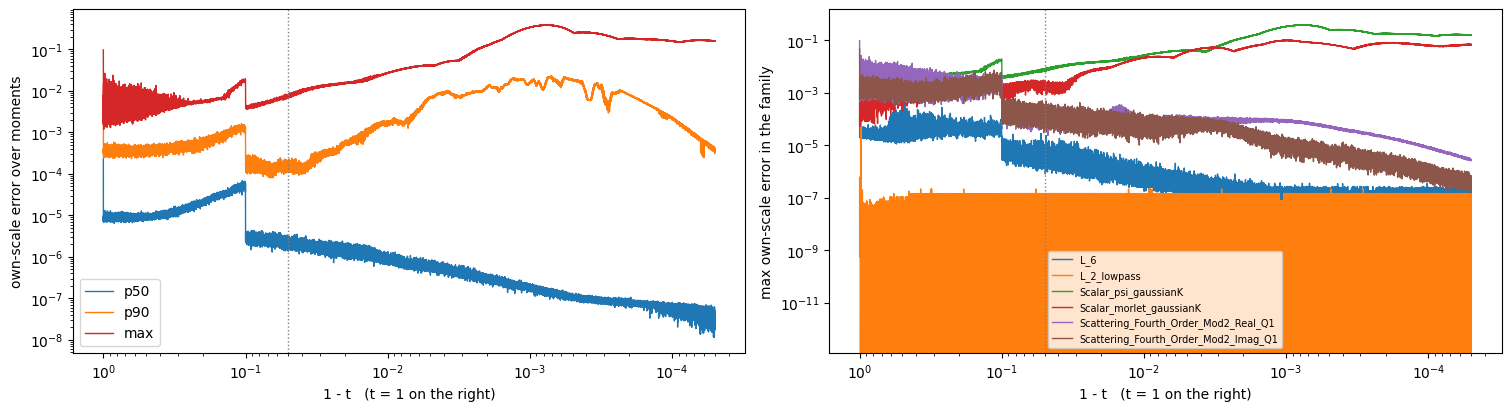


worst moments at the final step:
 stat name                                         own     target    walkers  t where own first > target
   11 Scalar_psi_gaussianK[1]                 1.59e-01  1.205e-03  1.014e-03                    0.957125
   23 Scalar_psi_gaussianK[13]                1.17e-01  1.489e-03  1.264e-03                    0.983438
   44 Scalar_psi_gaussianK[34]                9.05e-02  1.166e-03  1.651e-03                    0.985739
   12 Scalar_psi_gaussianK[2]                 8.50e-02  1.656e-03  1.515e-03                    0.981239
   88 Scalar_morlet_gaussianK[0]              6.87e-02  9.822e-04  9.147e-04                    0.982859
   13 Scalar_psi_gaussianK[3]                 6.11e-02  1.868e-03  1.754e-03                    0.995191
   10 Scalar_psi_gaussianK[0]                 3.44e-02  4.946e-04  4.776e-04                    0.982416
   45 Scalar_psi_gaussianK[35]                1.69e-02  2.635e-03  2.956e-03                    0.982929
   94 Scalar_morlet_g

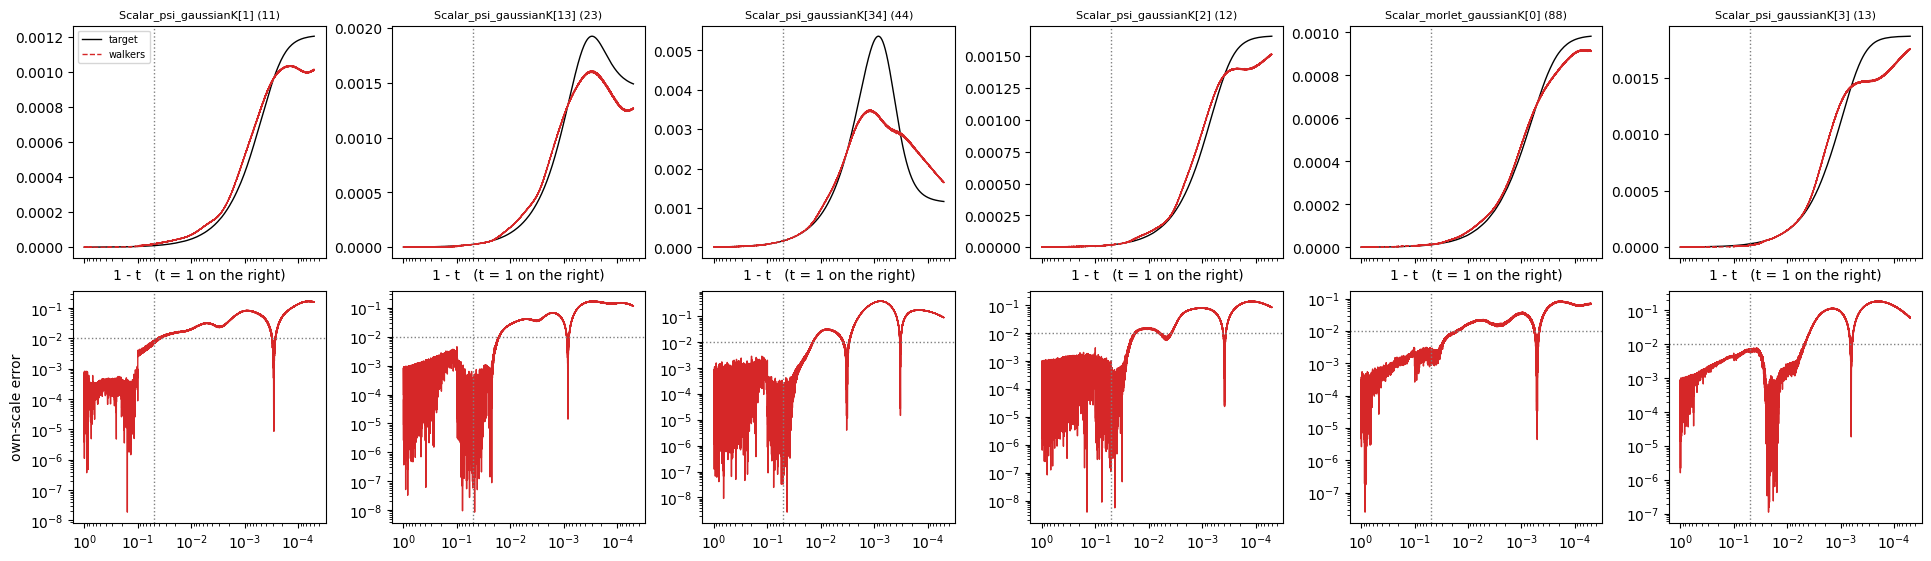

In [27]:
if aux is not None:
    E = aux['barphi_e'].double().numpy(); P = aux['barphi_p'].double().numpy()
    tM = t_grid[np.minimum(np.arange(len(E)), len(t_grid) - 1)]        # row 0 = before the first step
    keep = np.abs(E[-1]) > MOMENT_THRESHOLD
    kept = np.flatnonzero(keep)
    own = np.abs(E - P) / np.maximum(np.abs(E).max(0), 1e-300)
    own_k = own[:, keep]
    print(f'{keep.sum()}/{len(keep)} moments kept (|final target| > {MOMENT_THRESHOLD:g})')
    err_final = own_k[-1]
    print(f'final step, own scale: median {np.median(err_final):.2e}  p90 {np.percentile(err_final, 90):.2e}  '
          f'max {err_final.max():.2e}  above {ERR_TARGET:g}: {(err_final > ERR_TARGET).sum()}')

    fig, ax = plt.subplots(1, 2, figsize=(15, 4), constrained_layout=True)
    for q, c in [(50, 'C0'), (90, 'C1'), (100, 'C3')]:
        ax[0].plot(tx(tM), np.percentile(own_k, q, axis=1), color=c, lw=1, label=f'p{q}' if q < 100 else 'max')
    ax[0].set_yscale('log'); ax[0].set_ylabel('own-scale error over moments'); ax[0].legend()
    # where it fails, by family: mean over the moments of each family
    for f in families:
        s = family[kept] == f
        if s.any():
            ax[1].plot(tx(tM), own_k[:, s].max(1), lw=1, label=f)
    ax[1].set_yscale('log'); ax[1].set_ylabel('max own-scale error in the family'); ax[1].legend(fontsize=7)
    for a in ax: time_axis(a)
    savefig(fig, '3_moment_error'); plt.show()

    worst = kept[np.argsort(-err_final)[:12]]
    print(f'\nworst moments at the final step:')
    print(f'{"stat":>5} {"name":38s} {"own":>9} {"target":>10} {"walkers":>10} {"t where own first > target":>27}')
    for i in worst:
        above = np.flatnonzero(own[:, i] > ERR_TARGET)
        t_first = f'{tM[above[0]]:.6f}' if len(above) else '-'
        print(f'{i:5d} {labels[i]:38s} {own[-1, i]:9.2e} {E[-1, i]:10.3e} {P[-1, i]:10.3e} {t_first:>27}')

    nw = min(6, len(worst))
    fig, ax = plt.subplots(2, nw, figsize=(3.2 * nw, 5.5), constrained_layout=True, sharex='col', squeeze=False)
    for c, i in enumerate(worst[:nw]):
        ax[0, c].plot(tx(tM), E[:, i], 'k', lw=1, label='target')
        ax[0, c].plot(tx(tM), P[:, i], 'C3', lw=1, ls='--', label='walkers')
        ax[0, c].set_title(f'{labels[i]} ({i})', fontsize=8)
        ax[1, c].plot(tx(tM), own[:, i], 'C3', lw=1); ax[1, c].set_yscale('log')
        ax[1, c].axhline(ERR_TARGET, color='grey', ls=':', lw=1)
        time_axis(ax[0, c]); ax[1, c].axvline(1 - LATE_T, color='grey', ls=':', lw=1)
    ax[0, 0].legend(fontsize=7); ax[1, 0].set_ylabel('own-scale error')
    savefig(fig, '3b_worst_moments'); plt.show()
else:
    print('moment matching: needs the aux moments (written at the end of the run)')

## 4. Coefficient spikes: which θ explode, and why

θ_n has its own natural size, so a **spike** is measured against the statistic's own running median:
spike ratio = |θ_n(t)| / median of |θ_n| over the surrounding `SPIKE_WINDOW` steps (masked steps excluded).
For each statistic with a spike above `SPIKE_FACTOR`, the table gives what was happening at its largest
spike:

* **just unmasked** : the statistic was masked within the 50 steps before (a region that just refilled, with a tiny gradient)
* **in smallest direction** : the statistic is among the 3 top loadings of the smallest eigen-direction at the nearest logged step (near-copy)
* **κ** at the nearest logged step, and the **margin** (is some region about to empty?)

6 statistics with a spike > 100 x their running median
 stat name                                   peak ratio  t of peak #spikes just unmasked smallest dir       κ θ   margin
  109 Scalar_morlet_gaussianK[21]              3.21e+03   0.021330       4          True           no  6.23e+05     1.42
    8 L_6[8]                                   1.35e+03   0.021330       4         False           no  6.23e+05     1.42
    9 L_2_lowpass[0]                           8.48e+02   0.021330       2         False           no  6.23e+05     1.42
   22 Scalar_psi_gaussianK[12]                 5.77e+02   0.021330       2         False           no  6.23e+05     1.42
  100 Scalar_morlet_gaussianK[12]              5.64e+02   0.021510       3         False           no  6.23e+05     1.42
   93 Scalar_morlet_gaussianK[5]               1.81e+02   0.021330       1         False           no  6.23e+05     1.42


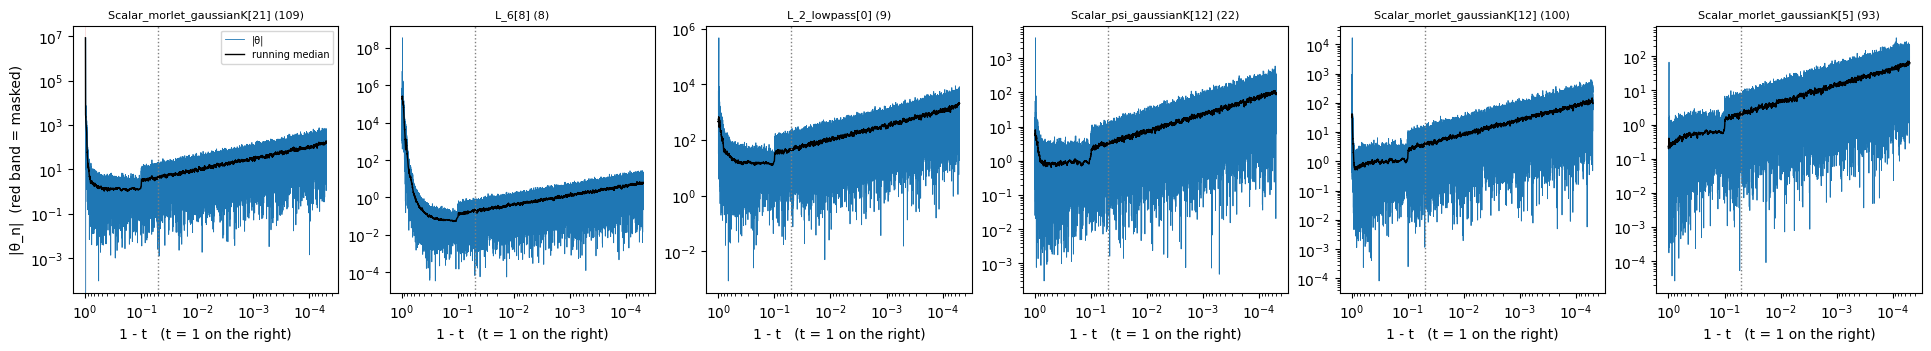

In [28]:
def running_median_abs(x, w):
    '''running median of |x| over w steps, NaN entries ignored (centred; edges use a shorter window).'''
    from numpy.lib.stride_tricks import sliding_window_view
    h = w // 2
    xp = np.pad(np.abs(x), ((h, h), (0, 0)), constant_values=np.nan)
    out = np.empty_like(x)
    for s in range(0, x.shape[0], 4096):                      # chunked: memory
        win = sliding_window_view(xp[s:s + 4096 + 2 * h], w, axis=0)
        out[s:s + 4096] = np.nanmedian(win, axis=-1)[:min(4096, x.shape[0] - s)]
    return out

if theta is not None:
    A = np.where(dead, np.nan, TH)
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)       # all-NaN windows (long masked stretches)
        med = running_median_abs(A, SPIKE_WINDOW)
    ratio = np.abs(A) / np.maximum(med, 1e-300)
    ratio[~np.isfinite(ratio)] = 0
    peak = ratio.max(0); kpk = ratio.argmax(0)
    spiky = np.flatnonzero(peak > SPIKE_FACTOR)
    spiky = spiky[np.argsort(-peak[spiky])]
    print(f'{len(spiky)} statistics with a spike > {SPIKE_FACTOR:g} x their running median')
    i0 = cols.index('top0') if cond is not None else None
    hdr = f'{"stat":>5} {"name":38s} {"peak ratio":>10} {"t of peak":>10} {"#spikes":>7} {"just unmasked":>13} {"smallest dir":>12} {"κ θ":>9} {"margin":>8}'
    print(hdr)
    spike_info = {}
    for i in spiky[:25]:
        k = kpk[i]
        just = bool(dead[max(0, k - 50):k, i].any())
        in_dir, kap_k, marg = '-', np.nan, np.nan
        if cond is not None:
            j = int(np.argmin(np.abs(C['theta'][:, 0] - k)))
            in_dir = 'yes' if i in C['theta'][j, i0:i0 + 3].astype(int) else 'no'
            kap_k, marg = kap['theta'][j], C['theta'][j, cols.index('margin')]
        n_sp = len(runs_of(ratio[:, i] > SPIKE_FACTOR))
        spike_info[i] = dict(peak=peak[i], t=tT[k], just=just, in_dir=in_dir)
        print(f'{i:5d} {labels[i]:38s} {peak[i]:10.2e} {tT[k]:10.6f} {n_sp:7d} {str(just):>13} {in_dir:>12} {kap_k:9.2e} {marg:8.3g}')

    ns = min(6, len(spiky))
    if ns:
        fig, ax = plt.subplots(1, ns, figsize=(3.2 * ns, 3.4), constrained_layout=True, squeeze=False)
        for c, i in enumerate(spiky[:ns]):
            a = ax[0, c]
            a.plot(tx(tT), np.abs(TH[:, i]), lw=0.6, color='C0', label='|θ|')
            a.plot(tx(tT), med[:, i], lw=1, color='k', label='running median')
            for s0, s1 in mask_table.get(i, []):
                a.axvspan(tx(tT[s0]), tx(tT[s1 - 1]), color='C3', alpha=0.15, lw=0)
            a.set_yscale('log'); a.set_title(f'{labels[i]} ({i})', fontsize=8); time_axis(a)
        ax[0, 0].legend(fontsize=7); ax[0, 0].set_ylabel('|θ_n|  (red band = masked)')
        savefig(fig, '4_spikes'); plt.show()
else:
    print('coefficient spikes: needs the saved theta_t (written at the end of the run)')

## 5. Discrepancy principle (supervisor's PS), replayed on the logged steps

At a logged corrector step, in the eigenbasis of the scaled G: $\mu_i$ eigenvalues, $\beta_i$ the
right-hand side (target − walker moments), $\nu_i$ its sampling-noise variance (from the walkers and
the interpolant samples). The ridge λ gives the residual $r_i(\lambda) = -\lambda\beta_i/(\mu_i+\lambda)$.
The principle picks the smallest λ whose residual reaches the noise level:

* **euclid** : $\sum_i r_i^2 = \sum_i \nu_i$
* **chi2** : $\sum_i r_i^2/\nu_i = n_{\rm live}$ (each direction compared to its own noise)

If even λ = ∞ (θ = 0, no correction at all) leaves a residual under the noise level, the
right-hand side is indistinguishable from noise at that step, and the principle says "do not correct".
Same computation as `notes/eps_conditioning_0930/discrepancy_from_cond.py`, both norms at once.

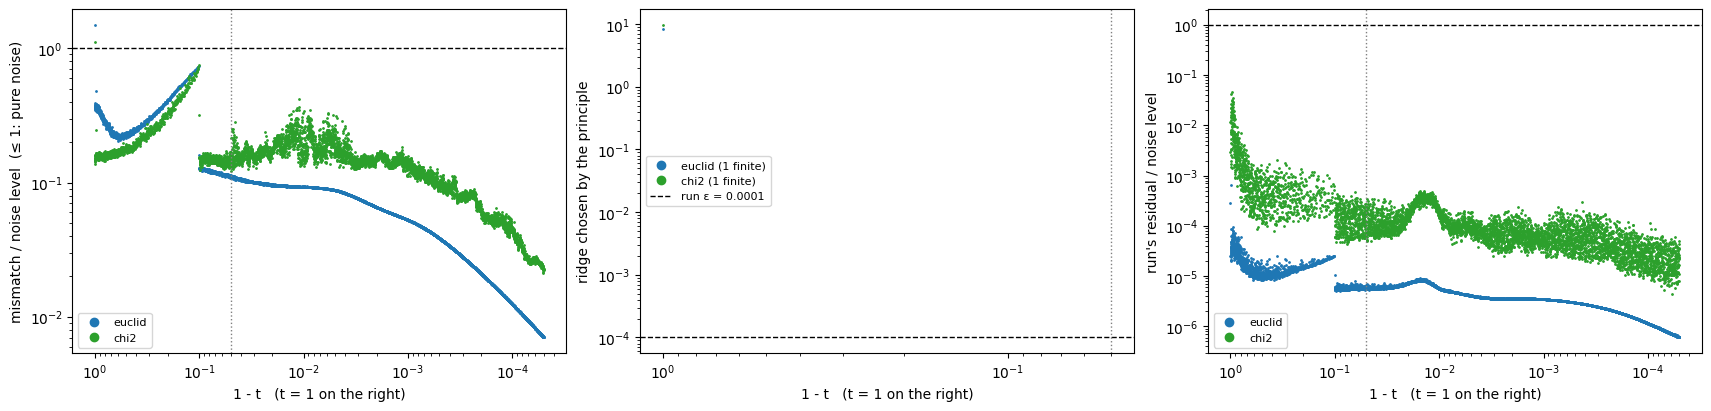

euclid: mismatch above noise at 1/6000 logged steps; median mismatch/noise 0.0871; median run residual/noise 4.03e-06; finite ridge median 8.31e+00
chi2  : mismatch above noise at 1/6000 logged steps; median mismatch/noise 0.149; median run residual/noise 8.91e-05; finite ridge median 9.68e+00


In [29]:
def discrepancy(spec, lam_run, norm):
    mu, beta, nu = spec[:, 0], spec[:, 1], spec[:, 2]
    n = len(spec); lam_dp = np.full(n, np.nan); res_run = np.full(n, np.nan); snr = np.full(n, np.nan)
    for j in range(n):
        ok = np.isfinite(mu[j]) & np.isfinite(beta[j]) & np.isfinite(nu[j])
        m, b, v = np.maximum(mu[j][ok], 1e-300), beta[j][ok], np.maximum(nu[j][ok], 1e-300)
        if not ok.any():
            continue
        w, tgt = (np.ones_like(m), v.sum()) if norm == 'euclid' else (1 / v, float(ok.sum()))
        R = lambda lam: np.sum(w * (lam * b / (m + lam)) ** 2)
        res_run[j] = np.sqrt(R(lam_run) / tgt)
        snr[j] = np.sqrt(np.sum(w * b ** 2) / tgt)          # = residual with no correction / noise level
        if snr[j] <= 1:
            lam_dp[j] = np.inf; continue
        lo, hi = -16.0, 8.0
        if R(10 ** lo) >= tgt:
            lam_dp[j] = 10 ** lo; continue
        for _ in range(80):
            mid = (lo + hi) / 2
            lo, hi = (mid, hi) if R(10 ** mid) < tgt else (lo, mid)
        lam_dp[j] = 10 ** hi
    return lam_dp, res_run, snr

if cond is not None and np.isfinite(S['theta'][:, 2]).any():
    DP = {nm: discrepancy(S['theta'], eps, nm) for nm in ('euclid', 'chi2')}
    fig, ax = plt.subplots(1, 3, figsize=(17, 4), constrained_layout=True)
    for (nm, (ld, rr, snr)), c in zip(DP.items(), ['C0', 'C2']):
        ax[0].plot(tx(tC['theta']), snr, '.', ms=2, color=c, label=nm)
        fin = np.isfinite(ld)
        ax[1].plot(tx(tC['theta'][fin]), ld[fin], '.', ms=2, color=c, label=f'{nm} ({fin.sum()} finite)')
        ax[2].plot(tx(tC['theta']), rr, '.', ms=2, color=c, label=nm)
    ax[0].axhline(1, color='k', ls='--', lw=1); ax[0].set_yscale('log')
    ax[0].set_ylabel('mismatch / noise level  (≤ 1: pure noise)')
    ax[1].axhline(eps, color='k', ls='--', lw=1, label=f'run ε = {eps:g}'); ax[1].set_yscale('log')
    ax[1].set_ylabel('ridge chosen by the principle')
    ax[2].axhline(1, color='k', ls='--', lw=1); ax[2].set_yscale('log')
    ax[2].set_ylabel("run's residual / noise level")
    for a in ax: time_axis(a); a.legend(markerscale=6, fontsize=8)
    savefig(fig, '5_discrepancy'); plt.show()
    for nm, (ld, rr, snr) in DP.items():
        fin = np.isfinite(ld)
        print(f'{nm:6s}: mismatch above noise at {fin.sum()}/{len(ld)} logged steps; '
              f'median mismatch/noise {np.nanmedian(snr):.3g}; median run residual/noise {np.nanmedian(rr):.3g}'
              + (f'; finite ridge median {np.median(ld[fin]):.2e}' if fin.any() else ''))
else:
    print('no noise estimate in the log (needs a run with --cond_every, theta solve)')

## 6. Summary per statistic

One row per statistic that shows up anywhere above: final moment error, masking, spikes, and how often
it is in the smallest eigen-direction of the θ solve. Sorted by final moment error.

In [30]:
rows = {}
def row(i):
    return rows.setdefault(i, dict(name=labels[i], err=np.nan, masked=0, spike=np.nan, small_dir=0))
if aux is not None:
    for i in kept[np.argsort(-err_final)[:15]]:
        row(i)['err'] = own[-1, i]
if theta is not None:
    for i in ever_dead: row(i)['masked'] = int(dead[:, i].sum())
    for i in spiky[:25]: row(i)['spike'] = peak[i]
if cond is not None:
    top3 = C['theta'][:, i0:i0 + 3].astype(int)
    for i, c in Counter(top3[top3 >= 0].tolist()).most_common(10): row(i)['small_dir'] = c
for i, d in rows.items():
    if aux is not None and keep[i]: d['err'] = own[-1, i]
    if theta is not None: d['masked'] = int(dead[:, i].sum()); d['spike'] = peak[i] if peak[i] > SPIKE_FACTOR else np.nan
    if cond is not None: d['small_dir'] = int((top3 == i).any(1).sum())
n_log = len(C['theta']) if cond is not None else 0
print(f'{"stat":>5} {"name":38s} {"final err":>10} {"#masked steps":>13} {"peak spike":>11} {"in smallest dir (θ)":>20}')
for i, d in sorted(rows.items(), key=lambda kv: -np.nan_to_num(kv[1]['err'], nan=-1)):
    sd = f'{d["small_dir"]}/{n_log}' if cond is not None else '-'
    print(f'{i:5d} {d["name"]:38s} {d["err"]:10.2e} {d["masked"]:13d} {d["spike"]:11.2e} {sd:>20}')

 stat name                                    final err #masked steps  peak spike  in smallest dir (θ)
   11 Scalar_psi_gaussianK[1]                  1.59e-01             0         nan               0/6000
   23 Scalar_psi_gaussianK[13]                 1.17e-01             0         nan               0/6000
   44 Scalar_psi_gaussianK[34]                 9.05e-02             0         nan               0/6000
   12 Scalar_psi_gaussianK[2]                  8.50e-02             0         nan               0/6000
   88 Scalar_morlet_gaussianK[0]               6.87e-02             0         nan               0/6000
   13 Scalar_psi_gaussianK[3]                  6.11e-02             0         nan               0/6000
   10 Scalar_psi_gaussianK[0]                  3.44e-02             0         nan               0/6000
   45 Scalar_psi_gaussianK[35]                 1.69e-02             0         nan               0/6000
   94 Scalar_morlet_gaussianK[6]               1.65e-02             0    